<a href="https://colab.research.google.com/github/tharun2128/DEEP-LEARNING/blob/main/ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK A: DATASET PREPARATION
--------------------------------------------------
Dataset loaded successfully!
Number of characters: 1115394

Sample text:

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor

Vocabulary size: 12633

Input shape: (204079, 10)
Training samples: 183671
Validation samples: 20408


TASK B: RNN MODEL
--------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)



TASK C: MODEL TRAINING
--------------------------------------------------
Epoch 1/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 137s 94ms/step - accuracy: 0.0452 - loss: 6.7279 - val_accuracy: 0.0642 - val_loss: 6.7225
Epoch 2/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 129s 90ms/step - accuracy: 0.0806 - loss: 6.0959 - val_accuracy: 0.0757 - val_loss: 6.6695
Epoch 3/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 133s 92ms/step - accuracy: 0.0935 - loss: 5.7770 - val_accuracy: 0.0789 - val_loss: 6.7108
Epoch 4/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 137s 89ms/step - accuracy: 0.1029 - loss: 5.5243 - val_accuracy: 0.0805 - val_loss: 6.7961
Epoch 5/5
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 129s 90ms/step - accuracy: 0.1115 - loss: 5.3047 - val_accuracy: 0.0784 - val_loss: 6.8993

FINAL RESULTS
----------------------------------------
Training Accuracy   : 0.1194
Validation Accuracy : 0.0784
Training Loss       : 5.3145
Validation Loss     : 6.8993


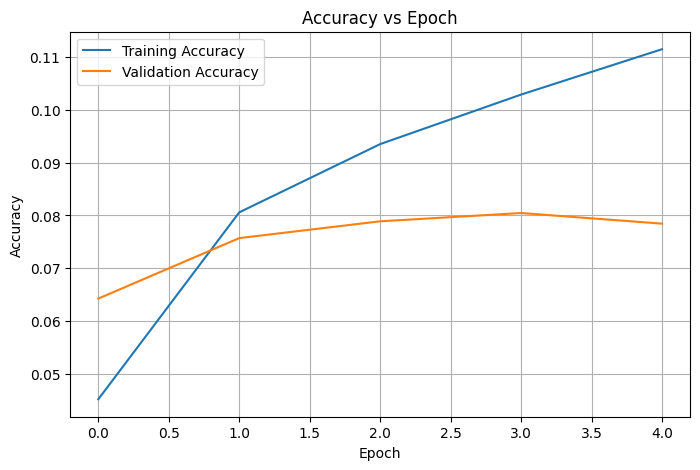

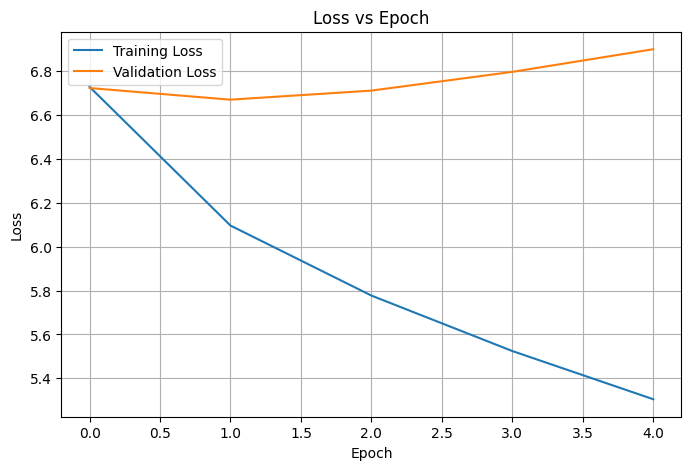



TASK D: TEXT GENERATION
--------------------------------------------------

Seed: the king
Generated text:
the king henry vi and i am a little thing to be a giant's a thing of a king and i am

Seed: my lord
Generated text:
my lord i have not been to me and i am not to the tower and i have heard you have a

Seed: thou art
Generated text:
thou art a little thing to be a giant's a thing to the king and i have done to be a little

Seed: what is
Generated text:
what is the king henry vi and i am a little thing to be a giant's a thing of a king and


OBSERVATION
--------------------------------------------------

The Simple RNN learned sequential patterns from the
Tiny Shakespeare dataset and generated new text by
predicting the next word from previous words.

Different seed inputs produced different generated
text samples. The model learned basic word and
contextual relationships from the training data.


Experiment completed successfully!


In [2]:
# ============================================================
# EXPT NO. 5 - RNN FOR TEXT GENERATION
# Name     : THARUN
# Roll No. : 24BAD126
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import requests

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# TASK A: DATASET PREPARATION
# ============================================================

print("TASK A: DATASET PREPARATION")
print("-" * 50)

# Download Tiny Shakespeare text directly
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

response = requests.get(url)

if response.status_code != 200:
    raise Exception("Could not download Tiny Shakespeare dataset.")

text = response.text.lower()

print("Dataset loaded successfully!")
print("Number of characters:", len(text))

print("\nSample text:\n")
print(text[:500])

# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("\nVocabulary size:", total_words)

# Convert words to integer sequences
sequences = tokenizer.texts_to_sequences([text])[0]

# ------------------------------------------------------------
# Generate input sequences
# ------------------------------------------------------------

sequence_length = 10

input_sequences = []

for i in range(sequence_length, len(sequences)):
    input_sequences.append(
        sequences[i-sequence_length:i+1]
    )

input_sequences = np.array(input_sequences)

# Inputs and target
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# ------------------------------------------------------------
# Train-validation split
# ------------------------------------------------------------

split = int(0.9 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

print("\nInput shape:", X.shape)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

# ============================================================
# TASK B: IMPLEMENTING THE RNN MODEL
# ============================================================

print("\n\nTASK B: RNN MODEL")
print("-" * 50)

model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=64
    ),
    SimpleRNN(128),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# TASK C: TRAINING AND PERFORMANCE EVALUATION
# ============================================================

print("\n\nTASK C: MODEL TRAINING")
print("-" * 50)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

train_loss, train_accuracy = model.evaluate(
    X_train, y_train, verbose=0
)

val_loss, val_accuracy = model.evaluate(
    X_val, y_val, verbose=0
)

print("\nFINAL RESULTS")
print("-" * 40)

print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")

# ------------------------------------------------------------
# Accuracy Graph
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

# ------------------------------------------------------------
# Loss Graph
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

# ============================================================
# TASK D: TEXT GENERATION
# ============================================================

print("\n\nTASK D: TEXT GENERATION")
print("-" * 50)

# Reverse dictionary
index_to_word = {
    index: word
    for word, index in tokenizer.word_index.items()
}

# ------------------------------------------------------------
# Text generation function
# ------------------------------------------------------------

def generate_text(seed_text, next_words=20):

    seed_text = seed_text.lower()

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = token_list[-sequence_length:]

        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        predicted = model.predict(
            token_list,
            verbose=0
        )

        predicted_id = np.argmax(
            predicted,
            axis=-1
        )[0]

        predicted_word = index_to_word.get(
            predicted_id,
            ""
        )

        if predicted_word == "":
            break

        seed_text += " " + predicted_word

    return seed_text


# ------------------------------------------------------------
# Generate multiple samples
# ------------------------------------------------------------

seed_inputs = [
    "the king",
    "my lord",
    "thou art",
    "what is"
]

for seed in seed_inputs:

    print("\nSeed:", seed)

    generated = generate_text(
        seed,
        next_words=20
    )

    print("Generated text:")
    print(generated)

# ============================================================
# OBSERVATION
# ============================================================

print("\n\nOBSERVATION")
print("-" * 50)

print("""
The Simple RNN learned sequential patterns from the
Tiny Shakespeare dataset and generated new text by
predicting the next word from previous words.

Different seed inputs produced different generated
text samples. The model learned basic word and
contextual relationships from the training data.
""")

print("\nExperiment completed successfully!")